In [9]:
import os
import pickle
import joblib
import math
import hdbscan
import numpy as np
import pandas as pd
import polars as pl
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import Birch, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch


In [10]:
df = pl.read_csv("nnary_features.csv")
df

filename,uni_1_count,uni_1_total_area,uni_1_avg_x,uni_1_avg_y,uni_2_count,uni_2_total_area,uni_2_avg_x,uni_2_avg_y,uni_3_count,uni_3_total_area,uni_3_avg_x,uni_3_avg_y,uni_4_count,uni_4_total_area,uni_4_avg_x,uni_4_avg_y,uni_5_count,uni_5_total_area,uni_5_avg_x,uni_5_avg_y,uni_6_count,uni_6_total_area,uni_6_avg_x,uni_6_avg_y,uni_7_count,uni_7_total_area,uni_7_avg_x,uni_7_avg_y,uni_8_count,uni_8_total_area,uni_8_avg_x,uni_8_avg_y,bi_1_2_count,bi_1_2_area_ratio,bi_1_2_avg_x,bi_1_2_avg_y,…,tri_4_5_8_avg_x,tri_4_5_8_avg_y,tri_4_6_7_count,tri_4_6_7_area_ratio_ij,tri_4_6_7_area_ratio_jk,tri_4_6_7_avg_x,tri_4_6_7_avg_y,tri_4_6_8_count,tri_4_6_8_area_ratio_ij,tri_4_6_8_area_ratio_jk,tri_4_6_8_avg_x,tri_4_6_8_avg_y,tri_4_7_8_count,tri_4_7_8_area_ratio_ij,tri_4_7_8_area_ratio_jk,tri_4_7_8_avg_x,tri_4_7_8_avg_y,tri_5_6_7_count,tri_5_6_7_area_ratio_ij,tri_5_6_7_area_ratio_jk,tri_5_6_7_avg_x,tri_5_6_7_avg_y,tri_5_6_8_count,tri_5_6_8_area_ratio_ij,tri_5_6_8_area_ratio_jk,tri_5_6_8_avg_x,tri_5_6_8_avg_y,tri_5_7_8_count,tri_5_7_8_area_ratio_ij,tri_5_7_8_area_ratio_jk,tri_5_7_8_avg_x,tri_5_7_8_avg_y,tri_6_7_8_count,tri_6_7_8_area_ratio_ij,tri_6_7_8_area_ratio_jk,tri_6_7_8_avg_x,tri_6_7_8_avg_y
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""40795.png""",2.0,3396.0,-38.60424,53.561837,1.0,2542.0,72.0,60.5,1,6998.5,35.884952,15.046177,1.0,615.0,114.5,60.5,1.0,621.0,23.5,69.5,1.0,882.0,-67.0,12.5,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""60259.png""",null,null,null,null,1.0,6864.0,-46.0,4.0,1,3596.0,26.0,33.0,1.0,1584.0,-98.0,4.0,1.0,506.0,8.5,79.0,1.0,682.0,39.5,79.0,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""45409.png""",2.0,4462.0,-2.314433,115.0,1.0,2156.0,-31.0,4.5,1,5624.0,-4.729107,58.016032,2.0,2085.0,-17.176259,63.252998,1.0,496.0,32.5,10.0,1.0,651.0,32.5,32.5,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""22733.png""",1.0,1855.0,43.5,80.5,1.0,2560.0,87.0,65.0,1,6431.0,-4.292723,59.388664,1.0,560.0,87.0,110.0,2.0,864.0,26.0,15.0,1.0,1134.0,-46.0,85.5,null,null,null,null,null,null,null,null,1.0,0.724609,65.25,72.75,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""25886.png""",1.0,1591.0,72.5,46.5,1.0,2433.5,73.43634,99.513321,1,6373.5,21.099893,60.111974,1.0,765.0,19.5,135.5,1.0,513.0,80.5,12.5,1.0,580.0,65.5,-13.0,null,null,null,null,null,null,null,null,1.0,0.653791,72.96817,73.006661,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""26753.png""",1.0,2135.5,39.887224,53.26957,1.0,2359.5,18.394646,150.781027,1,6447.0,-9.800062,58.278166,2.0,1338.0,-4.639013,130.914798,1.0,572.0,49.0,14.0,1.0,851.0,29.5,100.5,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null

In [11]:
df.shape

(80787, 425)

In [19]:
graphs = pickle.load(open("graphs.pkl", "rb"))

In [8]:
"3".split("e")

['3']

In [ ]:
all_types = [
    'common_room', 
    'master_room', 
    'living_room',  
    'balcony',       
    'bathroom',      
    'kitchen',     
    'storage',      
    'dining',        
]

G = 2
num_cells = G * G  
T = len(all_types)  
type_to_idx = {t: i for i, t in enumerate(all_types)}

print(f"Number of types T = {T}, grid per type = {G}×{G} ({num_cells} cells), total features = {T*num_cells}")

Number of types T = 8, grid per type = 2×2 (4 cells), total features = 32


In [ ]:
def extract_feature_matrix(floorplans, all_types, G=16, image_size=256):
    N = len(floorplans)
    T = len(all_types)
    type_to_idx = {t: i for i, t in enumerate(all_types)}

    D_area   = T * G * G
    D_counts = T * G * G
    D_total  = D_area + D_counts


    X = np.zeros((N, D_total), dtype=float)
    filenames = [None] * N

    for i, fp in enumerate(floorplans):
        filenames[i] = fp["filename"]
        rooms = fp["rooms"]

        for room in rooms:
            rtype = room["type"]
            if rtype not in type_to_idx:
  
                continue
            t_idx = type_to_idx[rtype]

            cx_raw, cy_raw = room["centroid"]

            cx = np.clip(cx_raw / image_size, 0.0, 1.0 - 1e-9)
            cy = np.clip(cy_raw / image_size, 0.0, 1.0 - 1e-9)

            gx = int(cx * G)
            gy = int(cy * G)
            cell_idx = gy * G + gx

            norm_area = room["area"] / (image_size * image_size)
            X[i, t_idx * (G * G) + cell_idx] += norm_area


            X[i, D_area + t_idx * (G * G) + cell_idx] += 1.0

    return X, filenames


X_raw, filenames = extract_feature_matrix(graphs, all_types, G=G, image_size=256)
print("feature matrix shape:", X_raw.shape)




Raw feature‐matrix shape: (80788, 64)


In [ ]:
def visualize_grid_indices(G=16, image_size=256):

    cell_size = image_size / G
    fig, ax = plt.subplots(figsize=(8, 8))


    for i in range(G + 1):
        x = i * cell_size
        ax.plot([x, x], [0, image_size], color='black', linewidth=0.5)  
        y = i * cell_size
        ax.plot([0, image_size], [y, y], color='black', linewidth=0.5) 

    for gy in range(G):
        for gx in range(G):
            idx = gy * G + gx
            x_center = (gx + 0.5) * cell_size
            display_gy = G - 1 - gy 
            y_center = (display_gy + 0.5) * cell_size
            ax.text(
                x_center,
                y_center,
                str(idx),
                ha='center',
                va='center',
                fontsize=6,
                color='red'
            )

    ax.set_xlim(0, image_size)
    ax.set_ylim(0, image_size)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{G}×{G} Grid (row‐major) with Cell Indices 0 to {G*G-1}")
    plt.tight_layout()
    plt.show()

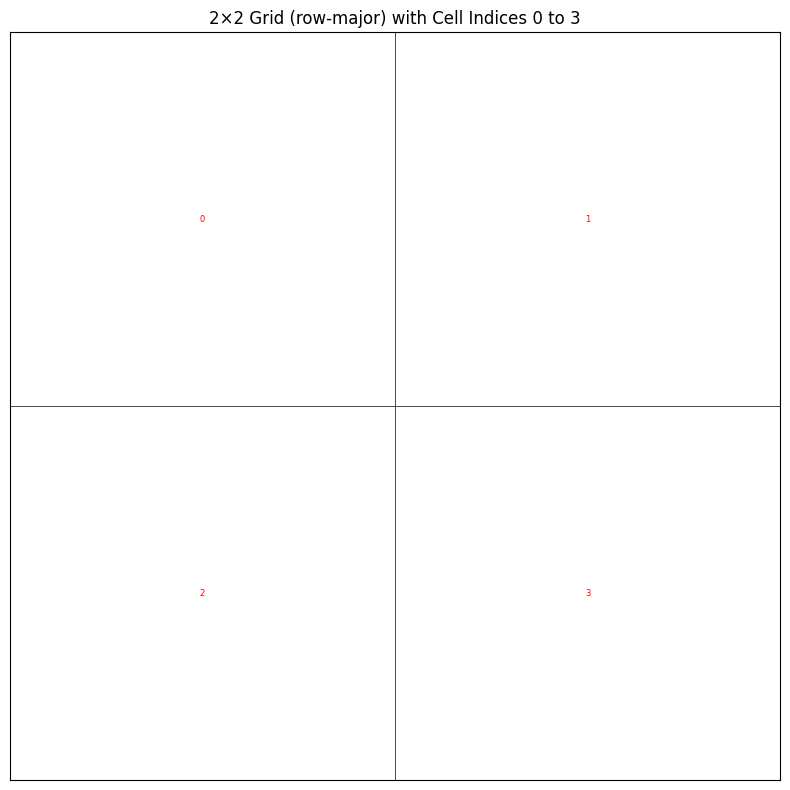

In [6]:
visualize_grid_indices(G=G, image_size=256)

In [ ]:
T = len(all_types)
total_feats = X_raw.shape[1]


G = int(math.sqrt(total_feats / (2 * T)))
# assert 2 * T * G * G == total_feats, "Unexpected feature‐count; need area+count with 2*T*G^2 == total_feats"


colnames = []

for t in all_types:
    for cell_idx in range(G * G):
        colnames.append(f"{t}_area_cell{cell_idx}")


for t in all_types:
    for cell_idx in range(G * G):
        colnames.append(f"{t}_count_cell{cell_idx}")

assert len(colnames) == total_feats


In [ ]:

df_feats = pd.DataFrame(X_raw, index=filenames, columns=colnames)
print(df_feats.iloc[:3, :8])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feats.values)

df_scaled = pd.DataFrame(X_scaled, index=filenames, columns=colnames)
print(df_scaled.iloc[:3, :8])

           common_room_area_cell0  common_room_area_cell1  \
2612.png                      0.0                0.034332   
40808.png                     0.0                0.026535   
36358.png                     0.0                0.035889   

           common_room_area_cell2  common_room_area_cell3  \
2612.png                      0.0                     0.0   
40808.png                     0.0                     0.0   
36358.png                     0.0                     0.0   

           master_room_area_cell0  master_room_area_cell1  \
2612.png                  0.00000                     0.0   
40808.png                 0.00000                     0.0   
36358.png                 0.05127                     0.0   

           master_room_area_cell2  master_room_area_cell3  
2612.png                 0.037209                0.000000  
40808.png                0.037842                0.022621  
36358.png                0.000000                0.000000  
           common_room_ar

In [ ]:
# with open("raw_feat_all_standard_quadron.pkl", "wb") as f:
#     pickle.dump(X_scaled, f)

In [ ]:
X_scaled = pickle.load(open("raw_feat_all_standard_quadron.pkl", "rb"))


In [ ]:
pca64 = PCA(n_components=64, random_state=0)
X_pca64 = pca64.fit_transform(X_scaled)  

In [5]:
linkage_matrix = sch.linkage(X_pca64[:40000], method='ward')

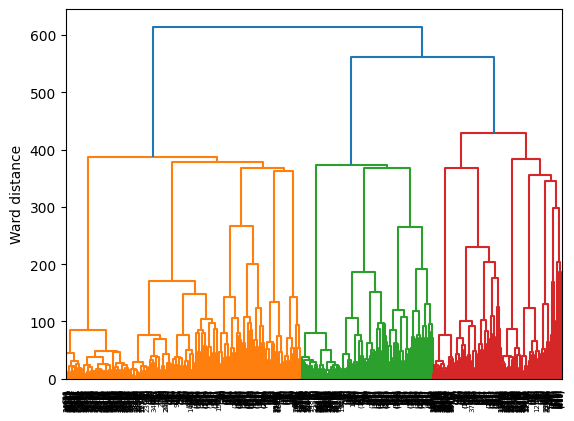

In [6]:
sch.dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.ylabel("Ward distance")
plt.show()

In [7]:
clusterer = AgglomerativeClustering(n_clusters=12, linkage='ward')
labels = clusterer.fit_predict(X_pca64[:40000])

In [9]:
joblib.dump(clusterer, 'agglo_40k_clusterer_quadron.joblib')
joblib.dump((X_pca64[:40000], labels), 'X40k_and_labels_quadron.joblib')

['X40k_and_labels_quadron.joblib']

In [10]:
clusterer = joblib.load('agglo_40k_clusterer_quadron.joblib')
X_first40k, labels = joblib.load('X40k_and_labels_quadron.joblib')

In [21]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_pca64[:40000], labels)

KNeighborsClassifier(n_neighbors=1)

In [22]:
X_rest = X_pca64[40000:]
labels_rest = knn.predict(X_rest)

In [11]:
num_data = 40000
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca64[:num_data, 0],
    X_pca64[:num_data, 3],
    c=(list(labels) + list(labels_rest))[:num_data],
    cmap="tab10",
    s=15,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Floorplans (colored by cluster)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

NameError: name 'labels_rest' is not defined

<Figure size 800x600 with 0 Axes>

In [12]:
# cnt = Counter(list(labels) + list(labels_rest))
cnt = Counter(list(labels))
for lbl, count in sorted(cnt.items()):
    if lbl == -1:
        print(f"  Noise points: {count}")
    else:
        print(f"  Cluster {lbl:>2}: {count} plans")

  Cluster  0: 6826 plans
  Cluster  1: 7260 plans
  Cluster  2: 4896 plans
  Cluster  3: 7140 plans
  Cluster  4: 5974 plans
  Cluster  5: 516 plans
  Cluster  6: 6249 plans
  Cluster  7: 213 plans
  Cluster  8: 496 plans
  Cluster  9: 89 plans
  Cluster 10: 235 plans
  Cluster 11: 106 plans


In [14]:
X_scaled[:num_data, :].shape

(40000, 64)

In [15]:
k_final = 12
num_data = 40000
cluster_centroids_16 = np.zeros((k_final, X_scaled.shape[1]), dtype=float)
X_first_n = X_scaled[:num_data]
for k in range(k_final):
    members = (labels == k)
    if np.any(members):
        cluster_centroids_16[k] = X_first_n[members].mean(axis=0)
    else:
        cluster_centroids_16[k] = 0.0

In [24]:
topn = 10
top_features_per_cluster = {}
for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]
    top_indices = np.argsort(centroid_vals)[-topn:][::-1]
    top_features = [(colnames[idx], centroid_vals[idx]) for idx in top_indices]
    top_features_per_cluster[k] = top_features

    print(f"\nCluster {k} — top {topn} features (feature_name, z‐score):")
    for feat_name, zval in top_features:
        print(f"  {feat_name:30s}  {zval:6.2f}")


Cluster 0 — top 10 features (feature_name, z‐score):
  master_room_count_cell1           1.63
  kitchen_count_cell2               1.60
  master_room_area_cell1            1.59
  kitchen_area_cell2                1.50
  storage_count_cell3               0.42
  storage_count_cell2               0.39
  balcony_area_cell0                0.33
  common_room_count_cell3           0.33
  storage_area_cell3                0.31
  bathroom_area_cell3               0.30

Cluster 1 — top 10 features (feature_name, z‐score):
  master_room_count_cell2           1.20
  master_room_area_cell2            1.18
  living_room_count_cell1           1.11
  living_room_area_cell1            1.08
  common_room_area_cell3            0.61
  common_room_count_cell3           0.55
  kitchen_count_cell1               0.43
  kitchen_area_cell1                0.38
  bathroom_count_cell0              0.33
  bathroom_area_cell0               0.31

Cluster 2 — top 10 features (feature_name, z‐score):
  master_room_coun

In [ ]:
N = 10
under_features_per_cluster = {}

for k in range(k_final):
    centroid_vals = cluster_centroids_16[k]

    neg_indices = np.argsort(centroid_vals)[:N]
    neg_feats = [(colnames[idx], centroid_vals[idx]) for idx in neg_indices]
    under_features_per_cluster[k] = neg_feats

    print(f"\nCluster {k} — top {N} under‐represented features (name, z‐score):")
    for feat_name, zval in neg_feats:
        print(f"  {feat_name:30s} {zval:6.2f}")


Cluster 0 — top 10 under‐represented features (name, z‐score):
  kitchen_count_cell1             -0.68
  master_room_count_cell2         -0.68
  master_room_area_cell2          -0.66
  kitchen_area_cell1              -0.63
  master_room_count_cell3         -0.43
  master_room_area_cell3          -0.42
  kitchen_count_cell0             -0.39
  kitchen_area_cell0              -0.35
  living_room_count_cell1         -0.35
  living_room_area_cell1          -0.34

Cluster 1 — top 10 under‐represented features (name, z‐score):
  master_room_count_cell3         -0.73
  master_room_area_cell3          -0.71
  living_room_count_cell3         -0.60
  living_room_area_cell3          -0.59
  living_room_count_cell2         -0.55
  living_room_area_cell2          -0.54
  common_room_count_cell1         -0.43
  common_room_area_cell1          -0.43
  master_room_count_cell0         -0.37
  kitchen_count_cell3             -0.36

Cluster 2 — top 10 under‐represented features (name, z‐score):
  kitche

In [26]:
cosim_matrix = cosine_similarity(X_scaled, cluster_centroids_16) 
cosim_matrix.shape

cosim_colnames = [f"cos_sim_{k}" for k in range(k_final)]
df_cosim = pd.DataFrame(cosim_matrix, index=filenames, columns=cosim_colnames)

df_features = pd.DataFrame(X_scaled, index=filenames, columns=colnames)

In [27]:
df_result = pd.concat([df_cosim, df_features, ], axis=1)[:num_data]
df_result['cluster'] = labels

In [28]:
df_result = df_result[[df_result.columns[-1]] + list(df_result.columns[:-1])]

In [29]:
df_result.to_csv("raw_feat_cluster_results_quadron.csv")